In [5]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
def generate_colony_centers(colony_radii, Xmin, Xmax, Ymin, Ymax, seed=None):
    """Place colony centers non-overlapping.
    colony_radii: list/tuple of radii.
    Returns list of tuples (colony_id, cx, cy, radius).
    """
    if seed is not None:
        np.random.seed(seed)

    centers = []
    for colony_id, radius in enumerate(colony_radii, start=1):
        if len(colony_radii) == 1:
            cx = 0.5 * (Xmin + Xmax)
            cy = 0.5 * (Ymin + Ymax)
            centers.append((colony_id, cx, cy, radius))
            continue

        tries = 0
        while True:
            tries += 1
            if tries > 10000:
                raise RuntimeError(
                    "Could not place non-overlapping colonies in bounding box; reduce number or size."
                )
            cx = np.random.uniform(Xmin + radius, Xmax - radius)
            cy = np.random.uniform(Ymin + radius, Ymax - radius)

            ok = True
            for _, x0, y0, r0 in centers:
                if np.hypot(cx - x0, cy - y0) < (radius + r0):
                    ok = False
                    break

            if ok:
                centers.append((colony_id, cx, cy, radius))
                break

    return centers


def generate_colony_positions(
    colony_specs,
    cell_volume,
    cell_type,
    Xmin,
    Xmax,
    Ymin,
    Ymax,
    Zmin=0,
    Zmax=0,
    vol_factor=1.5,
    packing_factor=1.1
):
    import math
    import numpy as np

    cell_radius = (3.0 * cell_volume / (4.0 * math.pi)) ** (1.0 / 3.0)
    print(f"Cell radius: {cell_radius:.2f} microns")

    # 👇 Apply slack here
    disc_spacing_x = cell_radius * math.sqrt(3) * packing_factor
    disc_spacing_y = cell_radius * 2.0 * packing_factor

    rows = []
    for colony_id, cx, cy, radius in colony_specs:
        x_start = cx - radius
        x_end = cx + radius
        y_start = cy - radius
        y_end = cy + radius

        row_index = 0
        x = x_start
        z = Zmin

        while x <= x_end:
            y = y_start
            while y <= y_end:
                # 👇 Correct hex offset
                px = x + (row_index % 2) * 0.5 * disc_spacing_x
                py = y

                if (px - cx) ** 2 + (py - cy) ** 2 <= radius ** 2:
                    if Xmin <= px <= Xmax and Ymin <= py <= Ymax:
                        rows.append(
                            {
                                "x": px,
                                "y": py,
                                "z": z,
                                "cell_type": cell_type,
                                "volume": np.random.uniform(
                                    cell_volume, cell_volume * vol_factor
                                ),
                                "colony_id": colony_id,
                            }
                        )
                y += disc_spacing_y

            x += disc_spacing_x
            row_index += 1

    return rows


In [12]:
Xmin, Xmax = -100, 100
Ymin, Ymax = -100, 100
Zmin, Zmax = 0, 0

cell_type = "ecoli"
cell_volume = 1.3

colony_sizes = [5.0]

centers = generate_colony_centers(
    colony_radii=colony_sizes,
    Xmin=Xmin,
    Xmax=Xmax,
    Ymin=Ymin,
    Ymax=Ymax,
    seed=12345,
)

rows = generate_colony_positions(
    colony_specs=centers,
    cell_volume=cell_volume,
    cell_type=cell_type,
    Xmin=Xmin,
    Xmax=Xmax,
    Ymin=Ymin,
    Ymax=Ymax,
    Zmin=Zmin,
    Zmax=Zmax,
)


df = pd.DataFrame(rows)
print("Generated", df.shape[0], "cells in", len(colony_sizes), "colonies")
print(df.groupby('colony_id').size())

csv_fname = f"../config/bacterial_colonies_n{len(colony_sizes)}.csv"
print("Saving cell positions to CSV file:", csv_fname)
df.to_csv(csv_fname, index=False)


Cell radius: 0.68 microns
Generated 38 cells in 1 colonies
colony_id
1    38
dtype: int64
Saving cell positions to CSV file: ../config/bacterial_colonies_n1.csv


(-150.0, 150.0)

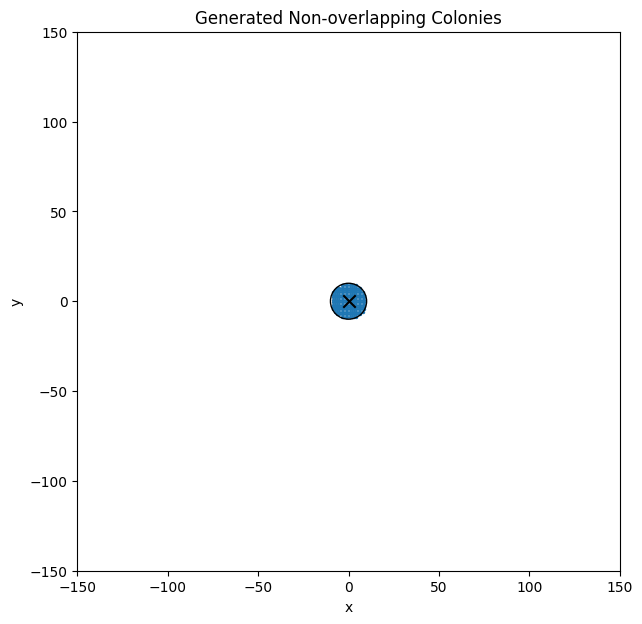

In [8]:
# Plot generated colonies for quick visual check
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
for cid, g in df.groupby('colony_id'):
    ax.scatter(g['x'], g['y'], s=2, label=f"colony_{cid}")

centers_df = pd.DataFrame(centers, columns=['colony_id', 'cx', 'cy', 'radius'])
ax.scatter(centers_df['cx'], centers_df['cy'], c='k', s=80, marker='x', label='centers')
for _, row in centers_df.iterrows():
    circle = plt.Circle((row['cx'], row['cy']), row['radius'], fill=False, edgecolor='k', linewidth=1)
    plt.gca().add_artist(circle)

ax.set_title('Generated Non-overlapping Colonies')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim((-150, 150))
ax.set_ylim((-150, 150))

